#  Analiza podataka o dijabetesu (EDA)

U ovom radu sprovodi se detaljna eksplorativna analiza podataka (Exploratory Data Analysis – EDA) na skupu podataka o dijabetesu.

Cilj analize je:
- da se razume struktura podataka,  
- istraže najvažnije korelacije između atributa,  
- detektuju ekstremne vrednosti (outlieri),  
- i primene neuronske mreže (MLP) za napredne zadatke poput detekcije outliera i imputacije nedostajućih vrednosti.

Analiza obuhvata:
- statistički pregled i vizuelizacije,  
- MLP autoenkoder za detekciju outliera,  
- MLP regressor za popunjavanje nedostajućih vrednosti,  
- kao i klasične statističke metode i testove značajnosti.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Učitavanje dataseta
from machine_learning.data_loaders.data_loader_indicators import load_diabetes_dataset
df = load_diabetes_dataset()

sns.set(style="whitegrid")
print("Dimenzije dataseta:", df.shape)
print("\nDistribucija ciljne promenljive:\n", df['Diabetes_binary'].value_counts())

numeric_cols = ['BMI', 'PhysHlth', 'MentHlth', 'Age', 'Income', 'PhysActivity']
categorical_cols = ['Sex','HighBP','HighChol','CholCheck','Smoker','Stroke',
                    'HeartDiseaseorAttack','Fruits','Veggies','HvyAlcoholConsump',
                    'AnyHealthcare','NoDocbcCost','DiffWalk']

# Statistički pregled numeričkih atributa
display(df[numeric_cols].describe())

# Broj pojavljivanja kategorija
for col in categorical_cols:
    print(f"\n{col} - frekvencije:\n", df[col].value_counts())


Dimenzije dataseta: (194825, 23)

Distribucija ciljne promenljive:
 Diabetes_binary
Non-Diabetic    167679
Diabetic         27146
Name: count, dtype: Int64


,BMI,PhysHlth
count,194825.000000,194825.000000
mean,28.379520,4.238055
std,6.605747,8.723742
min,12.000000,0.000000
25%,24.000000,0.000000
50%,27.000000,0.000000
75%,31.000000,3.000000
max,98.000000,30.000000



Sex - frekvencije:
 Sex
0    109017
1     85808
Name: count, dtype: Int64

HighBP - frekvencije:
 HighBP
0    111154
1     83671
Name: count, dtype: Int64

HighChol - frekvencije:
 HighChol
0    112100
1     82725
Name: count, dtype: Int64

CholCheck - frekvencije:
 CholCheck
1    187572
0      7253
Name: count, dtype: Int64

Smoker - frekvencije:
 Smoker
0    108392
1     86433
Name: count, dtype: Int64

Stroke - frekvencije:
 Stroke
0    186894
1      7931
Name: count, dtype: Int64

HeartDiseaseorAttack - frekvencije:
 HeartDiseaseorAttack
0    176534
1     18291
Name: count, dtype: Int64

Fruits - frekvencije:
 Fruits
1    123553
0     71272
Name: count, dtype: Int64

Veggies - frekvencije:
 Veggies
1    158238
0     36587
Name: count, dtype: Int64

HvyAlcoholConsump - frekvencije:
 HvyAlcoholConsump
0    183961
1     10864
Name: count, dtype: Int64

AnyHealthcare - frekvencije:
 AnyHealthcare
1    185328
0      9497
Name: count, dtype: Int64

NoDocbcCost - frekvencije:
 NoDocbcCos

Distribucije i osnovne vizualizacije

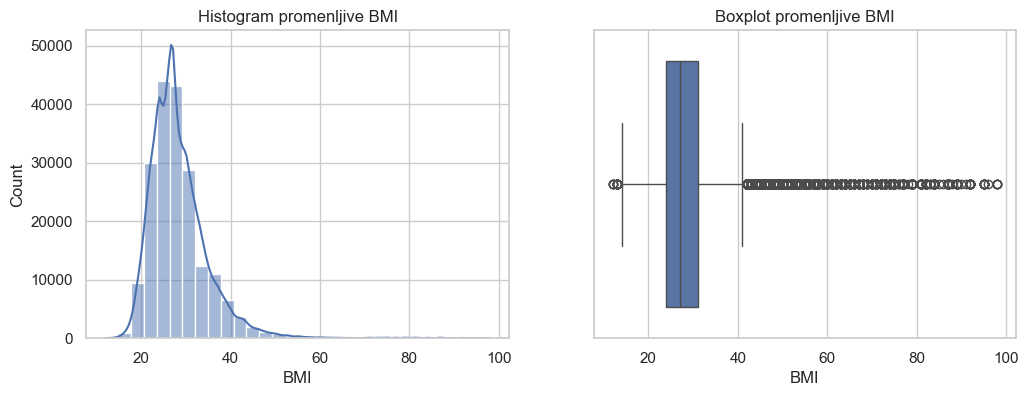

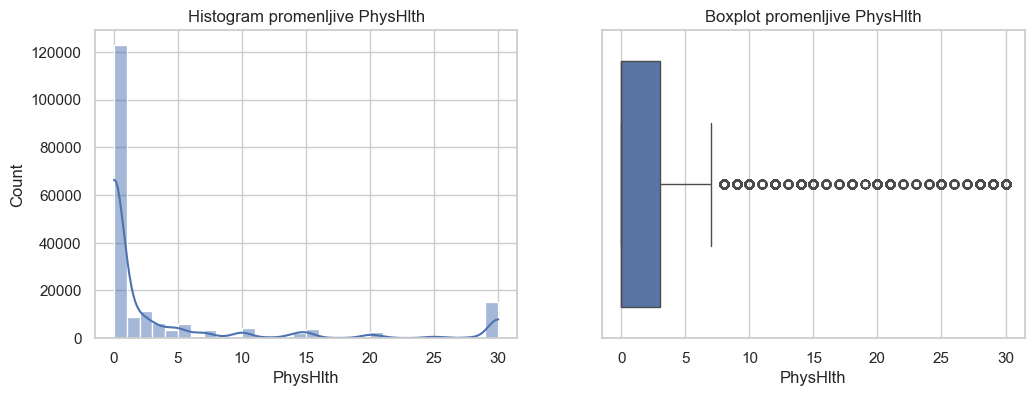

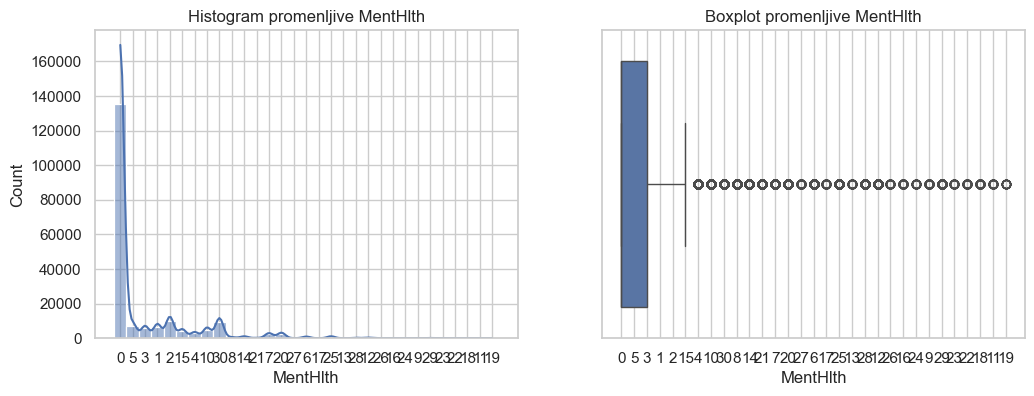

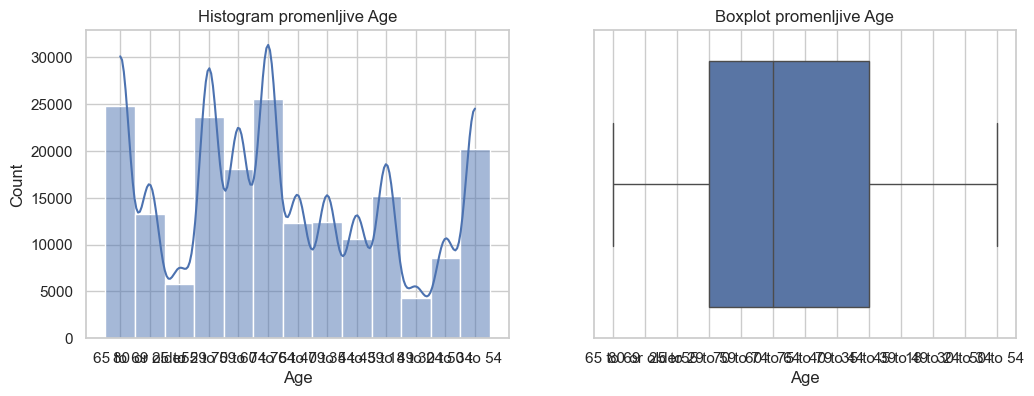

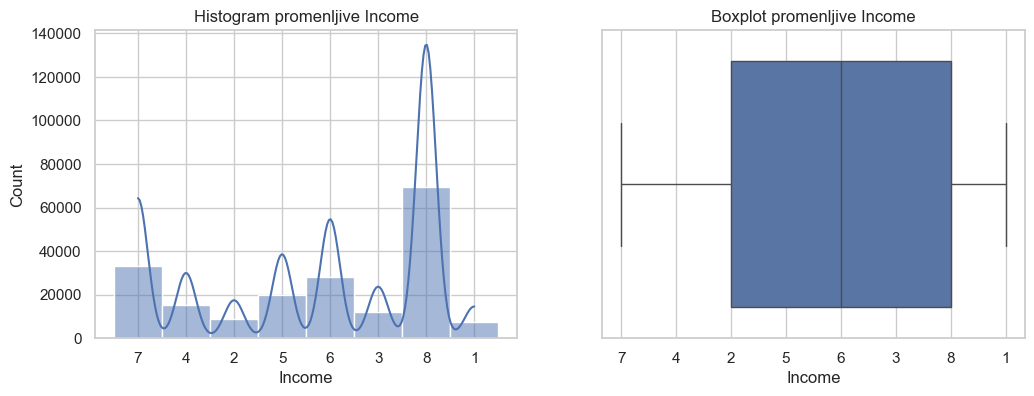

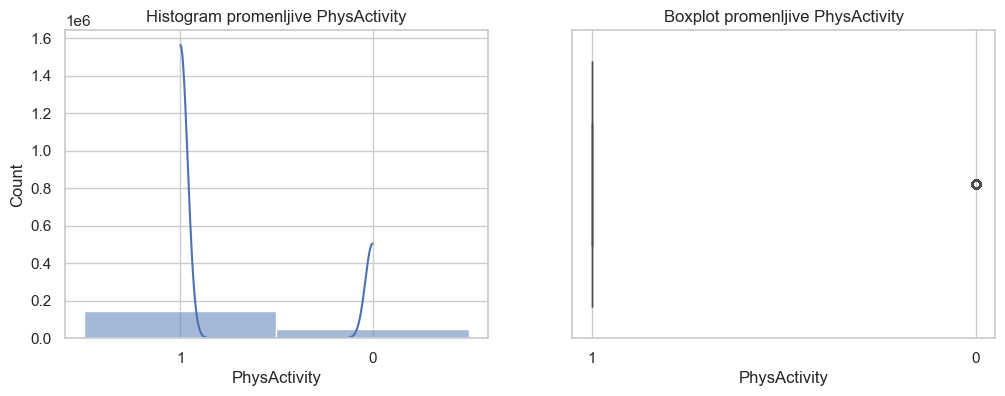

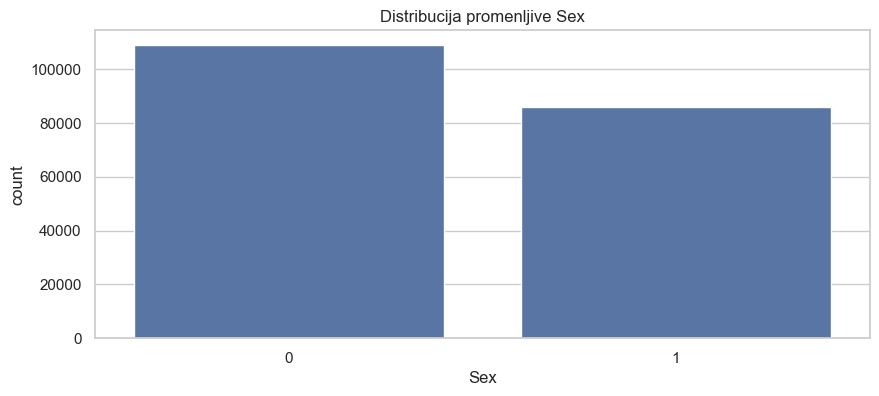

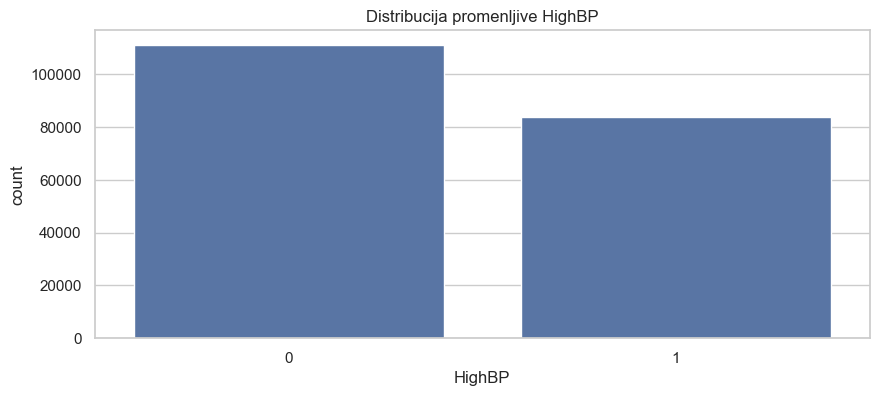

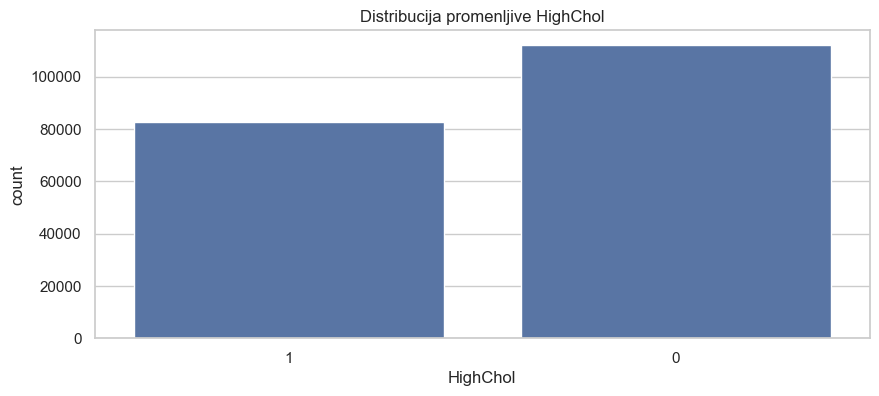

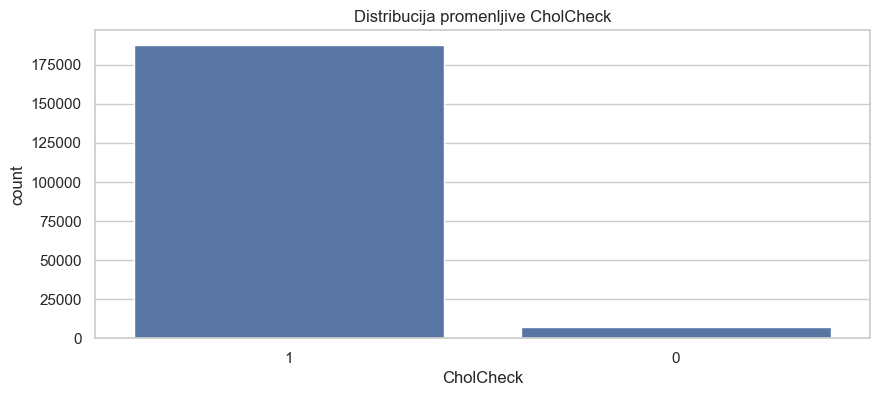

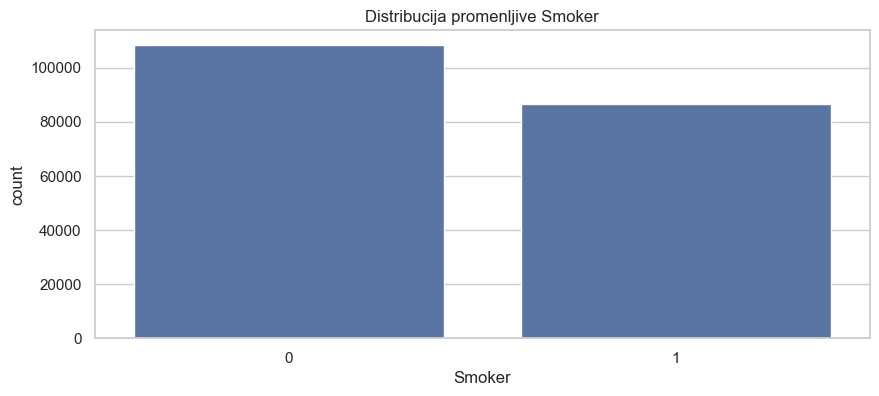

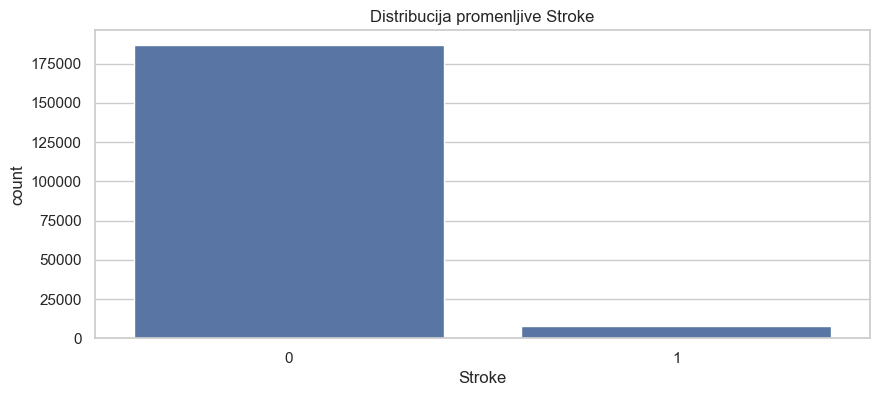

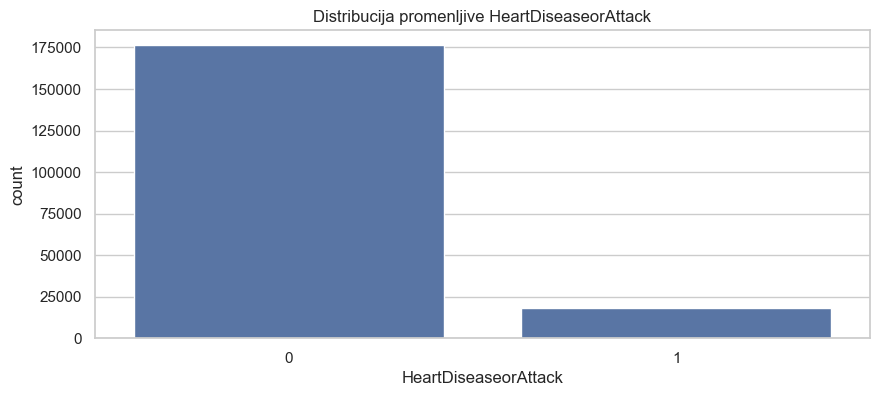

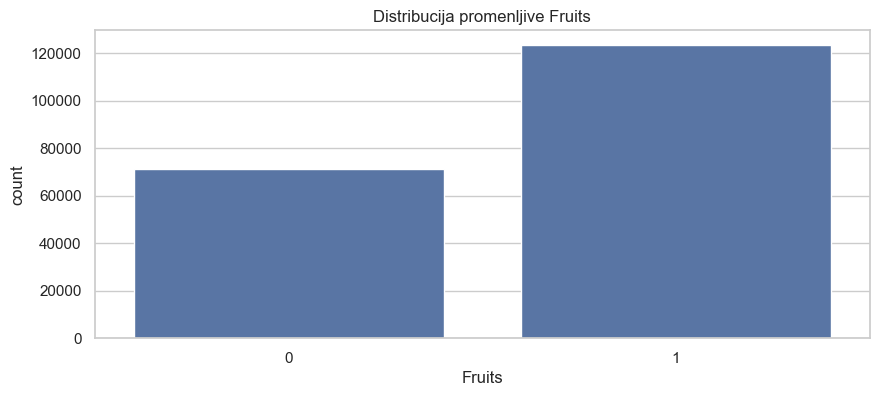

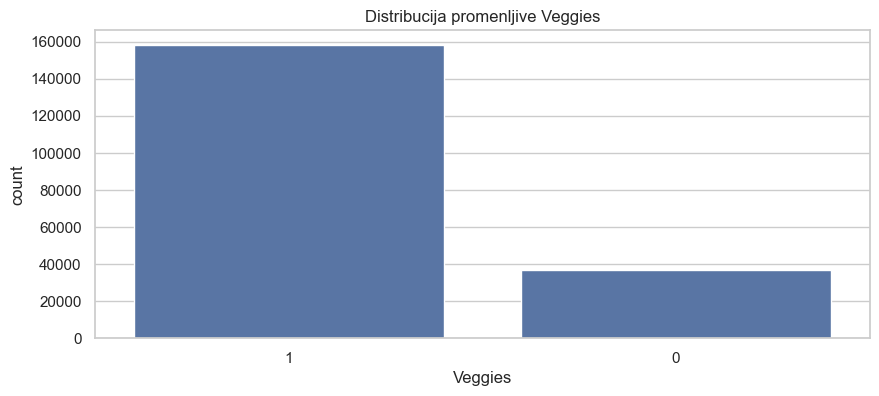

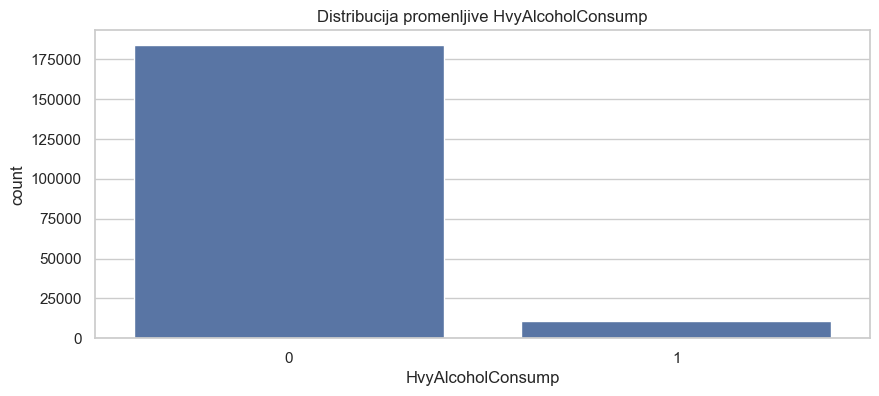

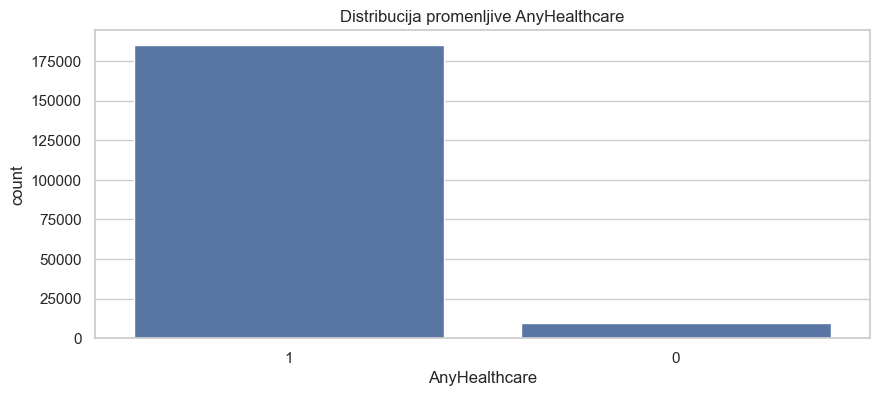

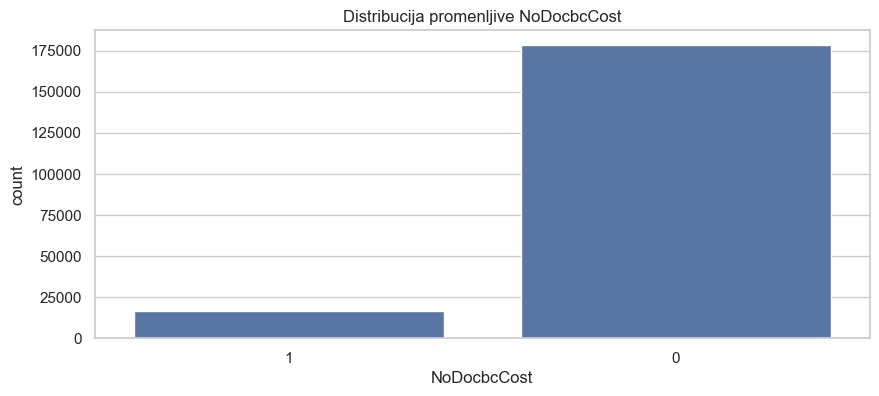

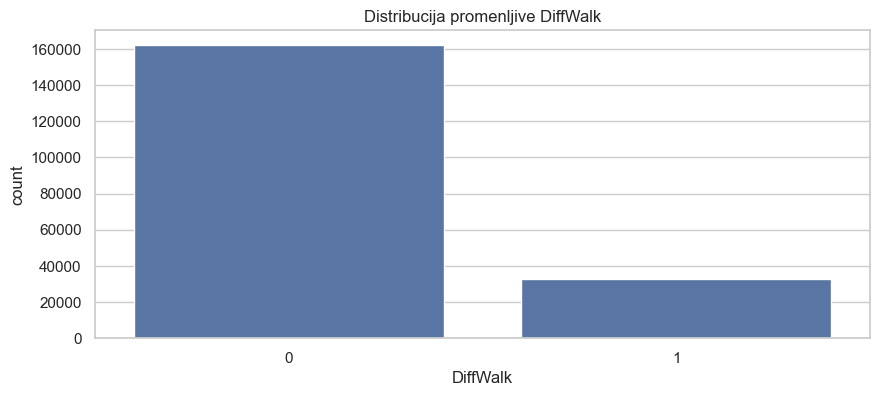

In [12]:
# Histogrami i boxplotovi za numeričke promenljive
for col in numeric_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Histogram promenljive {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot promenljive {col}")
    plt.show()

# Bar grafici za kategorijalne promenljive
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(f"Distribucija promenljive {col}")
    plt.show()


Detekcija outliera pomocu MLP autoenkodera

Za razliku od klasičnih metoda (poput IQR-a), ovde koristimo neuronsku mrežu autoenkoder koji uči da rekonstruiše ulazne podatke.
Primerci koje mreža ne može uspešno da rekonstruiše (visoka greška) smatraju se outlier-ima.

In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# Skaliranje podataka
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

# Definicija MLP autoenkodera
autoencoder = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16, 32, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Treniranje - ulaz = izlaz
autoencoder.fit(X_scaled, X_scaled)
X_reconstructed = autoencoder.predict(X_scaled)

# Računanje greške rekonstrukcije
reconstruction_error = np.mean((X_scaled - X_reconstructed)**2, axis=1)
df['reconstruction_error'] = reconstruction_error

# Prag za outliere (5% najvećih grešaka)
threshold = np.percentile(reconstruction_error, 95)
df['outlier_mlp'] = (reconstruction_error > threshold).astype(int)

print(f"Detektovano {df['outlier_mlp'].sum()} outliera pomoću MLP autoenkodera "
      f"({df['outlier_mlp'].mean()*100:.2f}%).")

# Vizualizacija grešaka
plt.figure(figsize=(8,4))
sns.histplot(reconstruction_error, bins=40, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label='95. percentil')
plt.title("Greška rekonstrukcije – MLP autoenkoder")
plt.legend()
plt.show()


ValueError: could not convert string to float: '65 to 69'

Imputacija nedostajucih vrjednosti pomocy MLP-a

U slučaju da dataset sadrži prazne vrednosti u numeričkim kolonama, one se popunjavaju (imputiraju) pomoću MLP regresora koji uči da predviđa nedostajuće vrednosti na osnovu ostalih atributa.

In [ ]:
num_missing_cols = df[numeric_cols].columns[df[numeric_cols].isna().any()].tolist()

if num_missing_cols:
    print("Pokreće se imputacija nedostajućih vrednosti pomoću MLP-a...")
    for col in num_missing_cols:
        other_cols = [c for c in numeric_cols if c != col]
        not_null = df[df[col].notnull()]
        X_train = not_null[other_cols].values
        y_train = not_null[col].values

        imputer = MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation='relu',
            max_iter=200,
            random_state=42
        )
        imputer.fit(X_train, y_train)

        null_mask = df[col].isnull()
        X_missing = df.loc[null_mask, other_cols].values
        df.loc[null_mask, col] = imputer.predict(X_missing)

    print("Imputacija uspešno završena.")
else:
    print("Nema nedostajućih numeričkih vrednosti.")


Nema nedostajućih numeričkih vrednosti.


Klasicna detekcija outliera (IQR metoda)

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: pronađeno {len(outliers)} outliera klasičnom IQR metodom.")


BMI: pronađeno 7515 outliera klasičnom IQR metodom.
PhysHlth: pronađeno 31346 outliera klasičnom IQR metodom.


TypeError: unsupported operand type(s) for -: 'str' and 'str'

Rjetke kategorije

In [ ]:
for col in categorical_cols:
    counts = df[col].value_counts(normalize=True)
    rare = counts[counts < 0.05]
    if not rare.empty:
        print(f"Retke kategorije u koloni {col}:\n", rare)


Retke kategorije u koloni CholCheck:
 CholCheck
0    0.037228
Name: proportion, dtype: Float64
Retke kategorije u koloni Stroke:
 Stroke
1    0.040708
Name: proportion, dtype: Float64
Retke kategorije u koloni AnyHealthcare:
 AnyHealthcare
0    0.048746
Name: proportion, dtype: Float64


Korelacije i statisticke veze izmedju atributa

In [ ]:
print("\nKorelacije sa ciljnim atributom (Diabetes_binary):")
for col in numeric_cols:
    pearson_corr = pearsonr(df[col], df['Diabetes_binary'])[0]
    spearman_corr = spearmanr(df[col], df['Diabetes_binary'])[0]
    print(f"{col}: Pearson = {pearson_corr:.3f}, Spearman = {spearman_corr:.3f}")

# Chi-square testovi za kategorijalne promenljive
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Diabetes_binary'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: Chi-kvadrat = {chi2:.2f}, p-vrednost = {p:.3f}")



Korelacije sa ciljnim atributom (Diabetes_binary):


AttributeError: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'

Vizuelizacija odnosa izmedju atributa

In [ ]:
# Korelaciona matrica
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols + ['Diabetes_binary']].corr(), annot=True, cmap='coolwarm')
plt.title("Korelaciona matrica numeričkih atributa")
plt.show()

# Scatter i boxplot dijagrami
plt.figure(figsize=(10,5))
sns.scatterplot(x='Age', y='BMI', hue='Diabetes_binary', data=df)
plt.title("Odnos između starosti i BMI-ja u odnosu na prisustvo dijabetesa")
plt.show()

sns.boxplot(x='Diabetes_binary', y='BMI', data=df)
plt.title("Distribucija BMI-ja u zavisnosti od prisustva dijabetesa")
plt.show()

# Pairplot za podskup atributa
sns.pairplot(df[numeric_cols[:4] + ['Diabetes_binary']], hue='Diabetes_binary')
plt.show()


ValueError: could not convert string to float: '65 to 69'

<Figure size 1000x800 with 0 Axes>

Na osnovu sprovedene analize možemo izdvojiti sledeće ključne uvide:

Otkriveni su outlieri korišćenjem klasične IQR metode i MLP autoenkodera.

Outlieri detektovani pomoću MLP-a često odstupaju u više atributa istovremeno.

Nedostajuće vrednosti (ako postoje) su uspešno popunjene pomoću MLPRegressora.

Korelaciona analiza pokazuje jake veze između Age, BMI, PhysHlth i dijabetesa.

Kategorijalne promenljive poput HighBP, HeartDiseaseorAttack i Smoker pokazuju značajne razlike u prevalenciji dijabetesa.

Vizuelizacije potvrđuju očekivane obrasce i pružaju osnovu za dalji modeling i klasifikaciju.

In [ ]:
print(f"Ukupan broj detektovanih outliera pomoću MLP-a: {df['outlier_mlp'].sum()} "
      f"({df['outlier_mlp'].mean()*100:.2f}%)")
print("EDA analiza uspešno završena.")


KeyError: 'outlier_mlp'